# Naive Bayes

## Imports

### Import data

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('../../data/model-ready.csv')
df.head()

,ISRC,Genre,Track,Album Name,Artist,All Time Rank,Track Score,Spotify Streams,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,AirPlay Spins,Pandora Streams,Pandora Track Stations,Shazam Counts,Explicit Track,Length,Releases,Registration Country,Followers,TikTok Views per Post,TikTok Impact,TikTok View-to-Like Ratio,TikTok Likes per Post,YouTube View-to-Like Ratio,Shazam Conversion Rate,Days Since Release,Label Prob,Label
0,QM24S2402528,Other,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,1,725.4,390470936,92,84274754,1713126,5767700,651565900,5332281936,40975,18004655,22931,2669262,0,155.1510,1,United States,847504.0,924.507505,0.000011,8.183795,112.968044,49.193524,0.000493,344,0.734589,1
1,USUG12400910,Rap,Not Like Us,Not Like Us,Kendrick Lamar,2,545.9,323703884,92,116347040,3486739,674700,35223547,208339025,40778,7780028,28444,1118279,1,274.1920,5,United States,38589324.0,308.787646,0.000003,5.914765,52.206158,33.368430,0.003444,336,0.721077,1
2,QZJ842400387,Other,i like the way you kiss me,I like the way you kiss me,Artemas,3,538.4,601309283,92,122599116,2228730,3025400,275154237,3369120610,74333,5022621,5639,5285340,0,143.1865,8,United States,1133424.0,1113.611625,0.000009,12.244480,90.948022,55.008485,0.001514,382,0.771418,1
3,USSM12209777,Other,Flowers,Flowers - Single,Miley Cyrus,4,444.9,2031280633,85,1096100899,10629796,7189811,1078757968,14603725994,1474799,190260277,203384,11822942,0,200.4530,30,United States,25620499.0,2031.169664,0.000002,13.537537,150.039802,103.115883,0.000753,814,0.799485,1
4,USUG12403398,Rap,Houdini,Houdini,Eminem,5,423.3,107034922,88,77373957,3670188,16400,26617282,266222834,12185,4493884,7006,457017,1,227.0320,20,United States,97970063.0,16233.099634,0.000210,10.001879,1622.906042,21.081736,0.001330,309,0.721544,1


### Import modules

For Naive Bayes, we use scikit-learn's MultinomialNB, GaussianNB, and CategoricalNB:
1. MultinomialNB: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB
2. GaussianNB: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB
3. CategoricalNB: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.CategoricalNB.html#sklearn.naive_bayes.CategoricalNB

For plotting, we use scikit-learn's ConfusionMatrixDisplay:
1. ConfusionMatrixDisplay: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

## Data Prep

### Custom function to reduce code repetition

In [47]:
def my_hist(df):
    custom_cmap = LinearSegmentedColormap.from_list('black_seagreen_diverge', ['black', 'white', 'mediumseagreen'])
    sns.heatmap(df.corr(), annot=True, cmap=custom_cmap, fmt='.2f', vmin=-1, vmax=1, center=0)
    plt.xticks(rotation=45)
    plt.show()

### Multinomial Naive Bayes

### Gaussian Naive Bayes

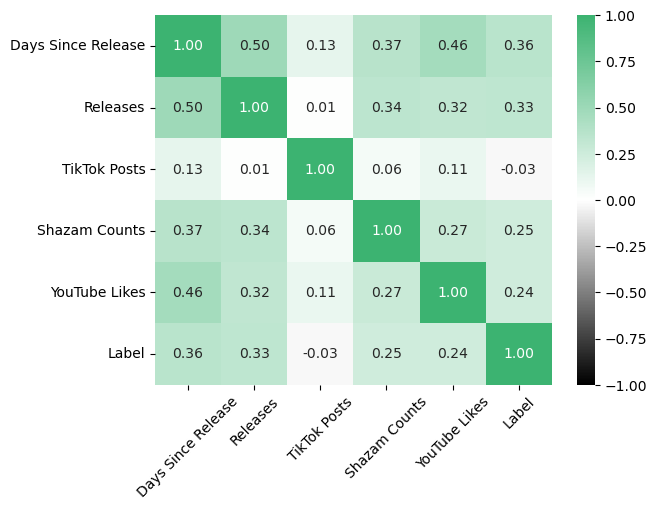

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Gaussian Naive Bayes dataset
df_gnb = df[['Days Since Release',
             'Releases',
             'TikTok Posts',
             'Shazam Counts',
             'YouTube Likes',
             'Label']]
df_gnb.head()

my_hist(df_gnb)

### Categorical Naive Bayes

## Model Data

### Custom classes to reduce code repetition

In [51]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

RSEED = 22
SKEW_THRESHOLD = 0.5

class MyScaler:
    def __init__(self):
        self.scaler_std = StandardScaler()
        
    def log(self, train_X, test_X):
        transformed_cols = []
        for col in train_X.columns:
            if pd.api.types.is_numeric_dtype(train_X[col]):
                skewness = train_X[col].skew()
                if skewness > SKEW_THRESHOLD:
                    transformed_cols.append(col)
        
        for col in transformed_cols:
            train_X[col] = np.log1p(train_X[col])
            test_X[col] = np.log1p(test_X[col])
            
        print(f'Log transformed (skewness > {SKEW_THRESHOLD}):\n{transformed_cols}\n')
            
        return train_X, test_X
        
    def standard(self, train_X, test_X):
        train_X = pd.DataFrame(self.scaler_std.fit_transform(train_X), columns=train_X.columns)
        test_X = pd.DataFrame(self.scaler_std.transform(test_X), columns=test_X.columns)
        return train_X, test_X
    
class MyResults:
    def __init__(self, y_true, y_pred, classes):
        self.y_true = y_true
        self.y_pred = y_pred
        self.classes = classes
        self.results_df = pd.DataFrame({
            'Actual': y_true.values,
            'Predicted': y_pred
        }, index=y_true.index)
        self.results_df['Correct'] = self.results_df['Actual'] == self.results_df['Predicted']
        
    def print_metrics(self):
        precision = precision_score(self.y_true, self.y_pred)
        recall = recall_score(self.y_true, self.y_pred)
        f1 = f1_score(self.y_true, self.y_pred)

        print(f'\nPrecision: {precision:.4f}')
        print(f'Recall:    {recall:.4f}')
        print(f'F1 Score:  {f1:.4f}')

    def plot_confusion_matrix(self, title='Confusion Matrix'):
        cm = confusion_matrix(self.y_true, self.y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=self.classes)
        custom_cmap = LinearSegmentedColormap.from_list(
            'black_to_seagreen', ['black', 'seagreen', 'mediumseagreen', 'mediumspringgreen']
        )
        disp.plot(cmap=custom_cmap)
        plt.title(title)
        plt.show()

    def plot_barcode(self, color_correct='mediumseagreen', color_incorrect='black'):
        correctness_map = self.results_df['Correct'].astype(int).values.reshape(1, -1)
        cmap = ListedColormap([color_incorrect, color_correct])
        num_samples = len(self.results_df)
        fig_width = num_samples * 0.01
        fig_height = 0.5

        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        ax.imshow(correctness_map, cmap=cmap, interpolation='nearest', aspect='auto')
        ax.axis('off')
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        plt.show()

### Multinomial Naive Bayes

### Gaussian Naive Bayes

Training Data: (3657 rows ~80.0%)



,Days Since Release,Releases,TikTok Posts,Shazam Counts,YouTube Likes,Label
2765,4112,88,339413,5306715,5528129,1
4200,673,21,1897,828611,309105,0
2605,4112,113,131095,7374291,6983846,1
3339,7765,153,95566,8538303,1687112,1
3502,1416,1,3196641,1728511,8586,0


Testing Data: (915 rows ~20.0%)



,Days Since Release,Releases,TikTok Posts,Shazam Counts,YouTube Likes,Label
3648,377,1,121600,122965,86574,0
3296,654,1,182364,163467,516029,0
2266,540,1,1380,538315,284943,0
681,368,1,182364,855525,1848749,1
1357,2577,12,1310523,3685380,5401876,1


Feature Names:
['Days Since Release' 'Releases' 'TikTok Posts' 'Shazam Counts'
 'YouTube Likes']

Class Names:
['Low', 'High']

Log transformed (skewness > 0.5):
['Days Since Release', 'Releases', 'TikTok Posts', 'Shazam Counts', 'YouTube Likes']


Precision: 0.7844
Recall:    0.7118
F1 Score:  0.7463


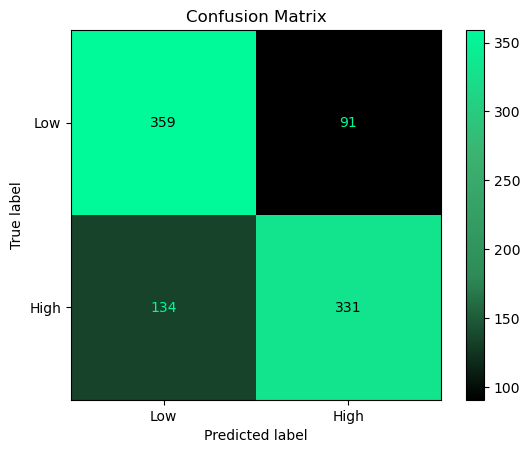

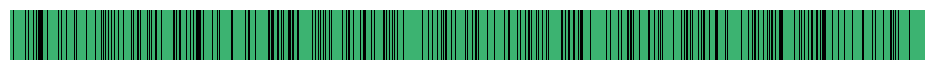

In [52]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2


# 2. Train-test split
train_df, test_df = train_test_split(df_gnb, test_size=TEST_SIZE, random_state=RSEED)

df_len, train_len, test_len = (len(x) for x in [df, train_df, test_df])

print(f'Training Data: ({train_len} rows ~{round(train_len/df_len, 2)*100}%)\n')
display(train_df.head())
print(f'Testing Data: ({test_len} rows ~{round(test_len/df_len, 2)*100}%)\n')
display(test_df.head())


# 3. X-y split
train_y = train_df['Label']
train_X = train_df.drop(['Label'], axis=1)

test_y = test_df['Label']
test_X = test_df.drop(['Label'], axis=1)

features = train_X.columns.values
classes = ['Low', 'High']
print(f'Feature Names:\n{features}\n')
print(f'Class Names:\n{classes}\n')


# 4. Normalization
scaler = MyScaler()

# -- Log transform
train_X, test_X = scaler.log(train_X, test_X)
# -- StandardScaler
train_X, test_X = scaler.standard(train_X, test_X)


# 5. Training
NB = GaussianNB()
NB.fit(train_X, train_y)


# 6. Prediction
prediction = NB.predict(test_X)


# 7. Results
results = MyResults(test_y, prediction, classes)

# -- Via metrics
results.print_metrics()
# -- Via confusion matrix
results.plot_confusion_matrix()
# -- Via prediction barcode
results.plot_barcode()

### Categorical Naive Bayes